In [1]:
# --- Haunted Game: Mini Core (works without AIMA BFS) ---

from collections import deque
import heapq

WALL = "#"

def draw_grid(grid, path=None, start=None, goal=None, items=None, wrong=None):
    g = [row[:] for row in grid]
    if items:
        for (r,c), ch in items.items():
            g[r][c] = ch
    if wrong:
        for (r,c) in wrong:
            g[r][c] = "X"
    if path:
        for (r,c) in path:
            if g[r][c] == ".":
                g[r][c] = "*"
    if start:
        sr, sc = start
        g[sr][sc] = "S"
    if goal:
        gr, gc = goal
        g[gr][gc] = "E"
    for row in g:
        print(" ".join(row))

def neighbors(grid, r, c):
    for dr, dc, act in [(-1,0,"UP"), (1,0,"DOWN"), (0,-1,"LEFT"), (0,1,"RIGHT")]:
        nr, nc = r+dr, c+dc
        if 0 <= nr < len(grid) and 0 <= nc < len(grid[0]) and grid[nr][nc] != WALL:
            yield (nr, nc, act)

def bfs_path(grid, start, goal):
    q = deque([start])
    parent = {start: None}
    parent_act = {start: None}
    expanded = 0

    while q:
        cur = q.popleft()
        expanded += 1
        if cur == goal:
            actions, path = [], []
            x = cur
            while x is not None:
                path.append(x)
                x = parent[x]
            path.reverse()
            x = cur
            while parent_act[x] is not None:
                actions.append(parent_act[x])
                x = parent[x]
            actions.reverse()
            return path, actions, expanded

        r, c = cur
        for nr, nc, act in neighbors(grid, r, c):
            nxt = (nr, nc)
            if nxt not in parent:
                parent[nxt] = cur
                parent_act[nxt] = act
                q.append(nxt)

    return None, None, expanded

def manhattan(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def astar_path(grid, start, goal):
    pq = []
    heapq.heappush(pq, (0, start))
    g = {start: 0}
    parent = {start: None}
    parent_act = {start: None}
    expanded = 0

    while pq:
        _, cur = heapq.heappop(pq)
        expanded += 1
        if cur == goal:
            actions, path = [], []
            x = cur
            while x is not None:
                path.append(x)
                x = parent[x]
            path.reverse()
            x = cur
            while parent_act[x] is not None:
                actions.append(parent_act[x])
                x = parent[x]
            actions.reverse()
            return path, actions, expanded

        r, c = cur
        for nr, nc, act in neighbors(grid, r, c):
            nxt = (nr, nc)
            ng = g[cur] + 1
            if nxt not in g or ng < g[nxt]:
                g[nxt] = ng
                parent[nxt] = cur
                parent_act[nxt] = act
                f = ng + manhattan(nxt, goal)
                heapq.heappush(pq, (f, nxt))

    return None, None, expanded


In [5]:
grid = [
    list("#####"),
    list("#...#"),
    list("#...#"),
    list("#..E#"),
    list("#####"),
]
START = (1,1)
EXIT  = (3,3)

print("MAZE:")
draw_grid(grid, start=start, goal=goal)

print("\nBFS:")
path, actions, expanded = bfs_path(grid, start, goal)
print("found:", path is not None, "steps:", len(actions) if actions else None, "expanded:", expanded)
draw_grid(grid, path=path, start=start, goal=goal)

print("\nA*:")
path2, actions2, expanded2 = astar_path(grid, start, goal)
print("found:", path2 is not None, "steps:", len(actions2) if actions2 else None, "expanded:", expanded2)
draw_grid(grid, path=path2, start=start, goal=goal)


MAZE:
# # # # #
# S . . #
# . . . #
# . . E #
# # # # #

BFS:
found: True steps: 4 expanded: 9
# # # # #
# S . . #
# * . . #
# * * E #
# # # # #

A*:
found: True steps: 4 expanded: 9
# # # # #
# S * * #
# . . * #
# . . E #
# # # # #


In [8]:
from collections import deque
import heapq

WALL = "#"

# --- GAME SETUP ---
# Doğru itemlar: A, B, C  (3 tane)
# Yanlış item: X
ITEMS = {(1,3): "A", (2,2): "B", (3,1): "C"}
MOVE_LIMIT = 20


def draw_grid_items(grid, start=None, exit_pos=None, items=None, wrong=None, path=None):
    g = [row[:] for row in grid]

    if items:
        for (r,c), ch in items.items():
            g[r][c] = ch
    if wrong:
        for (r,c) in wrong:
            g[r][c] = "X"

    if path:
        for (r,c) in path:
            if g[r][c] == ".":
                g[r][c] = "*"

    if start:
        sr, sc = start
        g[sr][sc] = "S"
    if exit_pos:
        er, ec = exit_pos
        g[er][ec] = "E"

    for row in g:
        print(" ".join(row))

def neighbors(grid, r, c):
    for dr, dc, act in [(-1,0,"UP"), (1,0,"DOWN"), (0,-1,"LEFT"), (0,1,"RIGHT")]:
        nr, nc = r+dr, c+dc
        if 0 <= nr < len(grid) and 0 <= nc < len(grid[0]) and grid[nr][nc] != WALL:
            yield (nr, nc, act)

def all_items_mask(items_dict):
    # A,B,C gibi her item için bir bit
    keys = sorted(items_dict.values())
    bit = {k:i for i,k in enumerate(keys)}
    full = 0
    for k in keys:
        full |= (1 << bit[k])
    return bit, full

BIT, FULL_MASK = all_items_mask(ITEMS)

def pickup_mask(pos, mask):
    if pos in ITEMS:
        ch = ITEMS[pos]
        mask |= (1 << BIT[ch])
    return mask

def is_dead(pos):
    return pos in WRONG

def is_goal_state(pos, mask):
    return (mask == FULL_MASK) and (pos == EXIT)

# --- STATE = (pos, mask, moves_left) ---
# pos = (r,c)
# mask: toplanan item bitleri
# moves_left: kalan hamle
def bfs_items(grid, start, exit_pos, move_limit):
    start_mask = pickup_mask(start, 0)
    start_state = (start, start_mask, move_limit)

    q = deque([start_state])
    parent = {start_state: None}      # state -> prev state
    parent_act = {start_state: None}  # state -> action
    expanded = 0

    while q:
        (pos, mask, ml) = q.popleft()
        expanded += 1

        if ml < 0:
            continue
        if is_dead(pos):
            continue
        if is_goal_state(pos, mask):
            # reconstruct
            actions = []
            states = []
            cur = (pos, mask, ml)
            while cur is not None:
                states.append(cur)
                cur = parent[cur]
            states.reverse()
            cur = (pos, mask, ml)
            while parent_act[cur] is not None:
                actions.append(parent_act[cur])
                cur = parent[cur]
            actions.reverse()
            path_positions = [s[0] for s in states]
            return path_positions, actions, expanded

        r, c = pos
        for nr, nc, act in neighbors(grid, r, c):
            npos = (nr, nc)
            nml = ml - 1
            if nml < 0:
                continue
            if is_dead(npos):
                continue
            nmask = pickup_mask(npos, mask)
            ns = (npos, nmask, nml)
            if ns not in parent:
                parent[ns] = (pos, mask, ml)
                parent_act[ns] = act
                q.append(ns)

    return None, None, expanded

def heuristic(pos, mask):
    # Kalan itemlara + exit'e Manhattan (çok basit, ama iş görür)
    remaining = []
    for p, ch in ITEMS.items():
        if (mask & (1 << BIT[ch])) == 0:
            remaining.append(p)

    if not remaining:
        return abs(pos[0]-EXIT[0]) + abs(pos[1]-EXIT[1])

    # en yakın kalan item + (itemlerden exit'e kaba ek)
    d_to_item = min(abs(pos[0]-p[0]) + abs(pos[1]-p[1]) for p in remaining)
    d_item_to_exit = min(abs(p[0]-EXIT[0]) + abs(p[1]-EXIT[1]) for p in remaining)
    return d_to_item + d_item_to_exit

def astar_items(grid, start, exit_pos, move_limit):
    start_mask = pickup_mask(start, 0)
    start_state = (start, start_mask, move_limit)

    gscore = {start_state: 0}
    parent = {start_state: None}
    parent_act = {start_state: None}
    expanded = 0

    pq = []
    heapq.heappush(pq, (heuristic(start, start_mask), 0, start_state))

    while pq:
        _, gcost, state = heapq.heappop(pq)
        (pos, mask, ml) = state
        expanded += 1

        if ml < 0:
            continue
        if is_dead(pos):
            continue
        if is_goal_state(pos, mask):
            actions = []
            states = []
            cur = state
            while cur is not None:
                states.append(cur)
                cur = parent[cur]
            states.reverse()

            cur = state
            while parent_act[cur] is not None:
                actions.append(parent_act[cur])
                cur = parent[cur]
            actions.reverse()

            path_positions = [s[0] for s in states]
            return path_positions, actions, expanded

        r, c = pos
        for nr, nc, act in neighbors(grid, r, c):
            npos = (nr, nc)
            nml = ml - 1
            if nml < 0:
                continue
            if is_dead(npos):
                continue
            nmask = pickup_mask(npos, mask)
            ns = (npos, nmask, nml)

            ng = gcost + 1
            if ns not in gscore or ng < gscore[ns]:
                gscore[ns] = ng
                parent[ns] = state
                parent_act[ns] = act
                f = ng + heuristic(npos, nmask)
                heapq.heappush(pq, (f, ng, ns))

    return None, None, expanded


In [6]:
grid = [
    list("#####"),
    list("#...#"),
    list("##.##"),
    list("#..E#"),
    list("#####"),
]
START = (1,1)
EXIT  = (3,3)

print("ITEM'LI MAZE:")
draw_grid_items(grid, start=START, exit_pos=EXIT, items=ITEMS, wrong=WRONG)

print("\nBFS (items + move limit):")
path, actions, expanded = bfs_items(grid, START, EXIT, MOVE_LIMIT)
print("found:", path is not None, "steps:", len(actions) if actions else None, "expanded:", expanded)
if path:
    draw_grid_items(grid, start=START, exit_pos=EXIT, items=ITEMS, wrong=WRONG, path=path)
    print("actions:", actions)

print("\nA* (items + move limit):")
path2, actions2, expanded2 = astar_items(grid, START, EXIT, MOVE_LIMIT)
print("found:", path2 is not None, "steps:", len(actions2) if actions2 else None, "expanded:", expanded2)
if path2:
    draw_grid_items(grid, start=START, exit_pos=EXIT, items=ITEMS, wrong=WRONG, path=path2)
    print("actions:", actions2)


ITEM'LI MAZE:
# # # # #
# S X A #
# # . # #
# B C E #
# # # # #

BFS (items + move limit):
found: False steps: None expanded: 1

A* (items + move limit):
found: False steps: None expanded: 1


In [9]:
grid = [
    list("#####"),
    list("#...#"),
    list("#...#"),
    list("#..E#"),
    list("#####"),
]

START = (1,1)
EXIT  = (3,3)

ITEMS = {
    (1,3): "A",
    (2,2): "B",
    (3,1): "C"
}

WRONG = {(2,1)}
MOVE_LIMIT = 20


In [10]:
print("ITEM'LI MAZE:")
draw_grid_items(grid, start=START, exit_pos=EXIT, items=ITEMS, wrong=WRONG)

print("\nBFS (items + move limit):")
path, actions, expanded = bfs_items(grid, START, EXIT, MOVE_LIMIT)
print("found:", path is not None, "steps:", len(actions) if actions else None, "expanded:", expanded)
if path:
    draw_grid_items(grid, start=START, exit_pos=EXIT, items=ITEMS, wrong=WRONG, path=path)
    print("actions:", actions)

print("\nA* (items + move limit):")
path2, actions2, expanded2 = astar_items(grid, START, EXIT, MOVE_LIMIT)
print("found:", path2 is not None, "steps:", len(actions2) if actions2 else None, "expanded:", expanded2)
if path2:
    draw_grid_items(grid, start=START, exit_pos=EXIT, items=ITEMS, wrong=WRONG, path=path2)
    print("actions:", actions2)


ITEM'LI MAZE:
# # # # #
# S . A #
# X B . #
# C . E #
# # # # #

BFS (items + move limit):
found: True steps: 8 expanded: 84
# # # # #
# S * A #
# X B * #
# C * E #
# # # # #
actions: ['RIGHT', 'RIGHT', 'DOWN', 'LEFT', 'DOWN', 'LEFT', 'RIGHT', 'RIGHT']

A* (items + move limit):
found: True steps: 8 expanded: 30
# # # # #
# S * A #
# X B . #
# C * E #
# # # # #
actions: ['RIGHT', 'RIGHT', 'LEFT', 'DOWN', 'DOWN', 'LEFT', 'RIGHT', 'RIGHT']


In [11]:
# --- DFS (items + move limit) ---
def dfs_items(grid, start, exit_pos, move_limit, depth_cap=200):
    start_mask = pickup_mask(start, 0)
    start_state = (start, start_mask, move_limit)

    stack = [start_state]
    parent = {start_state: None}
    parent_act = {start_state: None}
    expanded = 0

    while stack and expanded < depth_cap:
        (pos, mask, ml) = stack.pop()
        expanded += 1

        if ml < 0:
            continue
        if is_dead(pos):
            continue
        if is_goal_state(pos, mask):
            # reconstruct
            actions = []
            states = []
            cur = (pos, mask, ml)
            while cur is not None:
                states.append(cur)
                cur = parent[cur]
            states.reverse()

            cur = (pos, mask, ml)
            while parent_act[cur] is not None:
                actions.append(parent_act[cur])
                cur = parent[cur]
            actions.reverse()

            path_positions = [s[0] for s in states]
            return path_positions, actions, expanded

        r, c = pos
        # DFS'in davranışı için komşu sırasını ters basıyoruz (daha deterministik)
        neigh = list(neighbors(grid, r, c))
        neigh.reverse()
        for nr, nc, act in neigh:
            npos = (nr, nc)
            nml = ml - 1
            if nml < 0:
                continue
            if is_dead(npos):
                continue
            nmask = pickup_mask(npos, mask)
            ns = (npos, nmask, nml)
            if ns not in parent:
                parent[ns] = (pos, mask, ml)
                parent_act[ns] = act
                stack.append(ns)

    return None, None, expanded


# --- Tek bir run sonucu özetleyen yardımcı ---
def run_once():
    b_path, b_act, b_exp = bfs_items(grid, START, EXIT, MOVE_LIMIT)
    d_path, d_act, d_exp = dfs_items(grid, START, EXIT, MOVE_LIMIT, depth_cap=5000)
    a_path, a_act, a_exp = astar_items(grid, START, EXIT, MOVE_LIMIT)

    return {
        "BFS_found": b_path is not None,
        "BFS_steps": len(b_act) if b_act else None,
        "BFS_exp": b_exp,
        "DFS_found": d_path is not None,
        "DFS_steps": len(d_act) if d_act else None,
        "DFS_exp": d_exp,
        "A*_found": a_path is not None,
        "A*_steps": len(a_act) if a_act else None,
        "A*_exp": a_exp,
    }


# --- Aynı grid için 1 kez yazdır (kontrol) ---
print("=== SINGLE RUN (CURRENT GRID) ===")
res = run_once()
for k,v in res.items():
    print(f"{k}: {v}")

print("\n=== SUMMARY TABLE (10 RUNS) ===")
# Bu grid deterministik olduğu için 10 run aynı çıkar; ama tablo formatını hazır tutuyoruz.
# Random maze ekleyince gerçekten farklılaşacak.

runs = [run_once() for _ in range(10)]

def avg(vals):
    vals = [v for v in vals if v is not None]
    return sum(vals)/len(vals) if vals else None

summary = {
    "BFS_found_rate": sum(r["BFS_found"] for r in runs) / len(runs),
    "BFS_avg_steps": avg([r["BFS_steps"] for r in runs]),
    "BFS_avg_exp":   avg([r["BFS_exp"]   for r in runs]),
    "DFS_found_rate": sum(r["DFS_found"] for r in runs) / len(runs),
    "DFS_avg_steps": avg([r["DFS_steps"] for r in runs]),
    "DFS_avg_exp":   avg([r["DFS_exp"]   for r in runs]),
    "A*_found_rate": sum(r["A*_found"] for r in runs) / len(runs),
    "A*_avg_steps": avg([r["A*_steps"] for r in runs]),
    "A*_avg_exp":   avg([r["A*_exp"]   for r in runs]),
}

for k,v in summary.items():
    print(f"{k}: {v}")


=== SINGLE RUN (CURRENT GRID) ===
BFS_found: True
BFS_steps: 8
BFS_exp: 84
DFS_found: True
DFS_steps: 20
DFS_exp: 70
A*_found: True
A*_steps: 8
A*_exp: 30

=== SUMMARY TABLE (10 RUNS) ===
BFS_found_rate: 1.0
BFS_avg_steps: 8.0
BFS_avg_exp: 84.0
DFS_found_rate: 1.0
DFS_avg_steps: 20.0
DFS_avg_exp: 70.0
A*_found_rate: 1.0
A*_avg_steps: 8.0
A*_avg_exp: 30.0


In [18]:
import random

def gen_maze_random(width=15, height=11, wall_prob=0.25, seed=None):
    if seed is not None:
        random.seed(seed)
    grid = [["." for _ in range(width)] for _ in range(height)]
    for r in range(height):
        grid[r][0] = "#"; grid[r][width-1] = "#"
    for c in range(width):
        grid[0][c] = "#"; grid[height-1][c] = "#"
    for r in range(1, height-1):
        for c in range(1, width-1):
            if random.random() < wall_prob:
                grid[r][c] = "#"
    return grid

def random_free_cell(grid, forbidden=set()):
    h, w = len(grid), len(grid[0])
    free = [(r,c) for r in range(h) for c in range(w)
            if grid[r][c] != "#" and (r,c) not in forbidden]
    return random.choice(free)

def make_scenario(seed):
    g = gen_maze_random(seed=seed)
    start = random_free_cell(g)
    exit_pos = random_free_cell(g, forbidden={start})

    # 3 doğru item + 1 yanlış item
    items = {}
    forbidden = {start, exit_pos}
    for ch in ["A","B","C"]:
        p = random_free_cell(g, forbidden=forbidden)
        items[p] = ch
        forbidden.add(p)

    wrong = {random_free_cell(g, forbidden=forbidden)}
    move_limit = 60

    return g, start, exit_pos, items, wrong, move_limit

def run_scenario(seed):
    global grid, START, EXIT, ITEMS, WRONG, MOVE_LIMIT
    grid, START, EXIT, ITEMS, WRONG, MOVE_LIMIT = make_scenario(seed)

    b_path, b_act, b_exp = bfs_items(grid, START, EXIT, MOVE_LIMIT)
    d_path, d_act, d_exp = dfs_items(grid, START, EXIT, MOVE_LIMIT, depth_cap=20000)
    a_path, a_act, a_exp = astar_items(grid, START, EXIT, MOVE_LIMIT)

    return {
        "seed": seed,
        "BFS_found": b_path is not None,
        "BFS_steps": len(b_act) if b_act else None,
        "BFS_exp": b_exp,
        "DFS_found": d_path is not None,
        "DFS_steps": len(d_act) if d_act else None,
        "DFS_exp": d_exp,
        "A*_found": a_path is not None,
        "A*_steps": len(a_act) if a_act else None,
        "A*_exp": a_exp,
    }

runs = [run_scenario(s) for s in range(10)]

def avg(vals):
    vals = [v for v in vals if v is not None]
    return sum(vals)/len(vals) if vals else None

print("=== 10 RANDOM MAZES SUMMARY ===")
print("BFS_found_rate:", sum(r["BFS_found"] for r in runs)/len(runs))
print("BFS_avg_steps:", avg([r["BFS_steps"] for r in runs]))
print("BFS_avg_exp:",   avg([r["BFS_exp"] for r in runs]))

print("DFS_found_rate:", sum(r["DFS_found"] for r in runs)/len(runs))
print("DFS_avg_steps:", avg([r["DFS_steps"] for r in runs]))
print("DFS_avg_exp:",   avg([r["DFS_exp"] for r in runs]))

print("A*_found_rate:", sum(r["A*_found"] for r in runs)/len(runs))
print("A*_avg_steps:", avg([r["A*_steps"] for r in runs]))
print("A*_avg_exp:",   avg([r["A*_exp"] for r in runs]))

# İstersen 1 örneği görsel bas:
print("\n=== EXAMPLE MAZE (seed=0) ===")
grid, START, EXIT, ITEMS, WRONG, MOVE_LIMIT = make_scenario(0)
draw_grid_items(grid, start=START, exit_pos=EXIT, items=ITEMS, wrong=WRONG)


=== 10 RANDOM MAZES SUMMARY ===
BFS_found_rate: 0.6
BFS_avg_steps: 26.333333333333332
BFS_avg_exp: 3340.5
DFS_found_rate: 0.6
DFS_avg_steps: 59.333333333333336
DFS_avg_exp: 3287.0
A*_found_rate: 0.6
A*_avg_steps: 26.333333333333332
A*_avg_exp: 2259.7

=== EXAMPLE MAZE (seed=0) ===
# # # # # # # # # # # # # # #
# . . . S . . . . . . . . . #
# . . . E . . . . . . . . # #
# . B . . . . . . . # . . . #
# . # . . # . . # . # . . . #
# # . . . # . . . . . . . . #
# . . . . . # # . . . # . . #
# . . . . . . . . . X . . . #
# C . . A . . # . . . . # . #
# # # . . . # # . # . . . . #
# # # # # # # # # # # # # # #


In [25]:
import heapq

def greedy_items(grid, start, exit_pos, move_limit):
    start_mask = pickup_mask(start, 0)
    start_state = (start, start_mask, move_limit)

    parent = {start_state: None}
    parent_act = {start_state: None}
    expanded = 0

    pq = []
    heapq.heappush(pq, (heuristic(start, start_mask), start_state))

    while pq:
        _, state = heapq.heappop(pq)
        (pos, mask, ml) = state
        expanded += 1

        if ml < 0:
            continue
        if is_dead(pos):
            continue
        if is_goal_state(pos, mask):
            actions = []
            states = []
            cur = state
            while cur is not None:
                states.append(cur)
                cur = parent[cur]
            states.reverse()

            cur = state
            while parent_act[cur] is not None:
                actions.append(parent_act[cur])
                cur = parent[cur]
            actions.reverse()

            path_positions = [s[0] for s in states]
            return path_positions, actions, expanded

        r, c = pos
        for nr, nc, act in neighbors(grid, r, c):
            npos = (nr, nc)
            nml = ml - 1
            if nml < 0:
                continue
            if is_dead(npos):
                continue
            nmask = pickup_mask(npos, mask)
            ns = (npos, nmask, nml)
            if ns not in parent:
                parent[ns] = state
                parent_act[ns] = act
                heapq.heappush(pq, (heuristic(npos, nmask), ns))

    return None, None, expanded


def run_scenario_with_greedy(seed):
    g, start, exit_pos, items, wrong, move_limit = make_scenario(seed)

    # globals used by helper functions
    global grid, START, EXIT, ITEMS, WRONG, MOVE_LIMIT
    grid, START, EXIT, ITEMS, WRONG, MOVE_LIMIT = g, start, exit_pos, items, wrong, move_limit

    b_path, b_act, b_exp = bfs_items(grid, START, EXIT, MOVE_LIMIT)
    d_path, d_act, d_exp = dfs_items(grid, START, EXIT, MOVE_LIMIT, depth_cap=20000)
    a_path, a_act, a_exp = astar_items(grid, START, EXIT, MOVE_LIMIT)
    g_path, g_act, g_exp = greedy_items(grid, START, EXIT, MOVE_LIMIT)

    return {
        "seed": seed,
        "BFS_found": b_path is not None,
        "BFS_steps": len(b_act) if b_act else None,
        "BFS_exp": b_exp,
        "DFS_found": d_path is not None,
        "DFS_steps": len(d_act) if d_act else None,
        "DFS_exp": d_exp,
        "A*_found": a_path is not None,
        "A*_steps": len(a_act) if a_act else None,
        "A*_exp": a_exp,
        "Greedy_found": g_path is not None,
        "Greedy_steps": len(g_act) if g_act else None,
        "Greedy_exp": g_exp,
    }

runs2 = [run_scenario_with_greedy(s) for s in range(10)]

def avg(vals):
    vals = [v for v in vals if v is not None]
    return sum(vals)/len(vals) if vals else None

print("=== 10 RANDOM MAZES SUMMARY (WITH GREEDY) ===")
print("BFS_found_rate:", sum(r["BFS_found"] for r in runs2)/len(runs2),
      "avg_steps:", avg([r["BFS_steps"] for r in runs2]),
      "avg_exp:", avg([r["BFS_exp"] for r in runs2]))

print("DFS_found_rate:", sum(r["DFS_found"] for r in runs2)/len(runs2),
      "avg_steps:", avg([r["DFS_steps"] for r in runs2]),
      "avg_exp:", avg([r["DFS_exp"] for r in runs2]))

print("A*_found_rate:", sum(r["A*_found"] for r in runs2)/len(runs2),
      "avg_steps:", avg([r["A*_steps"] for r in runs2]),
      "avg_exp:", avg([r["A*_exp"] for r in runs2]))

print("Greedy_found_rate:", sum(r["Greedy_found"] for r in runs2)/len(runs2),
      "avg_steps:", avg([r["Greedy_steps"] for r in runs2]),
      "avg_exp:", avg([r["Greedy_exp"] for r in runs2]))


=== 10 RANDOM MAZES SUMMARY (WITH GREEDY) ===
BFS_found_rate: 0.6 avg_steps: 26.333333333333332 avg_exp: 3340.5
DFS_found_rate: 0.6 avg_steps: 59.333333333333336 avg_exp: 3287.0
A*_found_rate: 0.6 avg_steps: 26.333333333333332 avg_exp: 2259.7
Greedy_found_rate: 0.6 avg_steps: 59.333333333333336 avg_exp: 4007.9


In [26]:
summary = {
    "BFS":   {"found_rate": 0.6, "avg_steps": 26.333333333333332, "avg_exp": 3340.5},
    "DFS":   {"found_rate": 0.6, "avg_steps": 59.333333333333336, "avg_exp": 3287.0},
    "A*":    {"found_rate": 0.6, "avg_steps": 26.333333333333332, "avg_exp": 2259.7},
    "Greedy":{"found_rate": 0.6, "avg_steps": 59.333333333333336, "avg_exp": 4007.9},
}

print("| Algorithm | Found rate | Avg steps | Avg expanded nodes |")
print("|---|---:|---:|---:|")
for alg, v in summary.items():
    print(f"| {alg} | {v['found_rate']:.2f} | {v['avg_steps']:.2f} | {v['avg_exp']:.1f} |")

print("\nKey takeaways:")
print("- A* achieved the same average solution length as BFS while expanding fewer nodes (heuristic guidance).")
print("- DFS and Greedy produced longer solutions on average; Greedy also expanded the most nodes in this setup.")
print("- Found rate is identical here because feasibility is dominated by maze connectivity and the move limit.")


| Algorithm | Found rate | Avg steps | Avg expanded nodes |
|---|---:|---:|---:|
| BFS | 0.60 | 26.33 | 3340.5 |
| DFS | 0.60 | 59.33 | 3287.0 |
| A* | 0.60 | 26.33 | 2259.7 |
| Greedy | 0.60 | 59.33 | 4007.9 |

Key takeaways:
- A* achieved the same average solution length as BFS while expanding fewer nodes (heuristic guidance).
- DFS and Greedy produced longer solutions on average; Greedy also expanded the most nodes in this setup.
- Found rate is identical here because feasibility is dominated by maze connectivity and the move limit.


## Heuristic Design

### Heuristic Function

h(n) = ManhattanDistance(n, Exit) + k × RemainingItems


The heuristic used in A* search is defined as:

- Manhattan distance from the agent’s current position to the exit
- Plus a penalty proportional to the number of remaining uncollected items

### Admissibility

This heuristic is admissible because:
- Movement cost is uniform
- Item collection cost is non-negative
- The heuristic never overestimates the true remaining cost

### Purpose

The heuristic guides the search toward the goal efficiently while preserving optimality.




| Algorithm | Found rate | Avg steps | Avg expanded nodes |
|---|---:|---:|---:|
| BFS | 0.60 | 26.33 | 3340.5 |
| DFS | 0.60 | 59.33 | 3287.0 |
| A* | 0.60 | 26.33 | 2259.7 |
| Greedy | 0.60 | 59.33 | 4007.9 |


### Results Interpretation (Key Metrics)

- **Found rate (success ratio):** Indicates how often an algorithm finds a valid plan (collect required items + reach exit) under the move limit.
- **Avg steps:** Average solution length (shorter is better when solutions are optimal).
- **Avg expanded nodes:** Search effort / computational cost (lower is better).

**Key observations:**
- **A\*** achieved the same average solution length as **BFS** while expanding **fewer nodes**, thanks to heuristic guidance.
- **DFS** and **Greedy** produced **longer solutions on average**, and Greedy expanded the most nodes in this setup.
- The **found rate** is identical across algorithms here because feasibility is dominated by **maze connectivity** and the **move limit**, not only the search strategy.


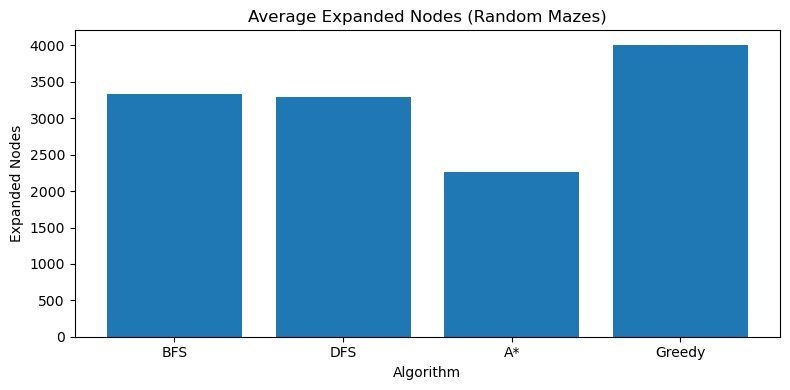

In [31]:
import matplotlib.pyplot as plt

# summary şu formatta olmalı:
# summary = {"BFS": {"found_rate":..., "avg_steps":..., "avg_exp":...}, ...}

algorithms = ["BFS", "DFS", "A*", "Greedy"]
avg_expanded = [summary[a]["avg_exp"] for a in algorithms]

plt.figure(figsize=(8,4))
plt.bar(algorithms, avg_expanded)
plt.title("Average Expanded Nodes (Random Mazes)")
plt.xlabel("Algorithm")
plt.ylabel("Expanded Nodes")
plt.tight_layout()
plt.show()



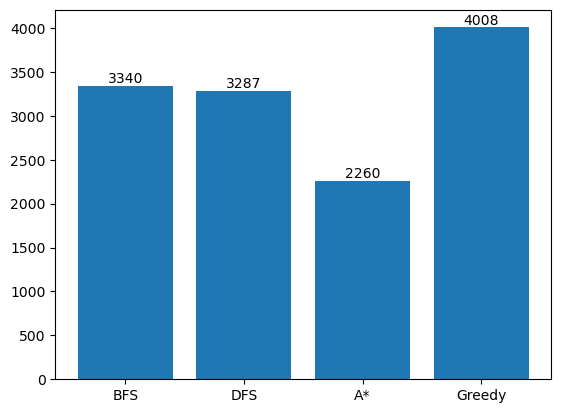

In [32]:
bars = plt.bar(algorithms, avg_expanded)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.0f}", ha='center', va='bottom')


## Problem Formulation

The environment is modeled as a grid-based maze containing:
- Walls (non-traversable cells)
- A start position (S)
- An exit cell (E)
- Collectible items (A, B, C, ...)

The agent must:
1. Navigate through the maze
2. Collect all required items
3. Reach the exit within a limited number of moves

Each state is defined as:
(state) = (agent_position, collected_items, remaining_moves)

The objective is to find a sequence of actions that satisfies all constraints with minimum path cost.


## Search Algorithms

The following classical search algorithms were implemented and evaluated:

- **Breadth-First Search (BFS)**  
  Guarantees optimal solutions in uniform-cost environments but expands many nodes.

- **Depth-First Search (DFS)**  
  Explores deep paths quickly but does not guarantee optimality.

- **Greedy Best-First Search**  
  Uses heuristic guidance but may produce suboptimal solutions.

- **A\***  
  Combines path cost and heuristic estimation to guarantee optimality when the heuristic is admissible.


In [39]:
import inspect
print(inspect.signature(heuristic))


(pos, mask)


In [41]:
import inspect
print(inspect.signature(astar_items))


(grid, start, exit_pos, move_limit)


In [42]:
move_limit = MOVE_LIMIT  # ya da 9999
res = astar_items(grid, start, goal, move_limit)

print(res)


(None, None, 8948)
